In [10]:
import sys
print(sys.executable)

c:\Users\dell\Desktop\disease_prediction_system\.venv\Scripts\python.exe


In [12]:
import sys
!{sys.executable} -m pip install pandas

  Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 9.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.6/9.9 MB 9.6 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.9 MB 9.5 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.9 MB 8.5 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 9.0 MB/s  0:00:01
Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl (12.4 MB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- ------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
print("Pandas working ✅")

Pandas working ✅


In [14]:
import pandas
print(pandas.__file__)

c:\Users\dell\Desktop\disease_prediction_system\.venv\Lib\site-packages\pandas\__init__.py


In [16]:
import sys
!{sys.executable} -m pip install numpy matplotlib seaborn scikit-learn xgboost

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

print("All libraries working ✅")

All libraries working ✅


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.impute import SimpleImputer

import pickle
import os

In [40]:
os.makedirs("models", exist_ok=True)

In [62]:
def train_model(df, target_column, model_name):
    
    print(f"\n📊 Training for {model_name}...\n")
    
    # Features & Target
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    
    print("Unique y:", y.unique())
    
    # 🔥 FIX: Encode target if not numeric
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
        print("Target encoded ✅")
    
    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    # Models
    models = {
        "Logistic": LogisticRegression(max_iter=1000),
        "RandomForest": RandomForestClassifier(),
        "SVM": SVC(),
        "XGBoost": XGBClassifier()
    }
    
    best_acc = 0
    best_model = None
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        
        print(f"{name} Accuracy: {acc}")
        
        if acc > best_acc:
            best_acc = acc
            best_model = model
    
    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, best_model.predict(X_test)), annot=True)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()
    
    # Save Model
    pickle.dump(best_model, open(f"models/{model_name}.pkl", "wb"))
    
    print(f"✅ Model Saved for {model_name}\n")
    
    return best_acc


📊 Training for diabetes_model...

Logistic Accuracy: 0.7532467532467533
RandomForest Accuracy: 0.7402597402597403
SVM Accuracy: 0.7272727272727273
XGBoost Accuracy: 0.7207792207792207

🏆 Best Model: Logistic (0.7532467532467533)


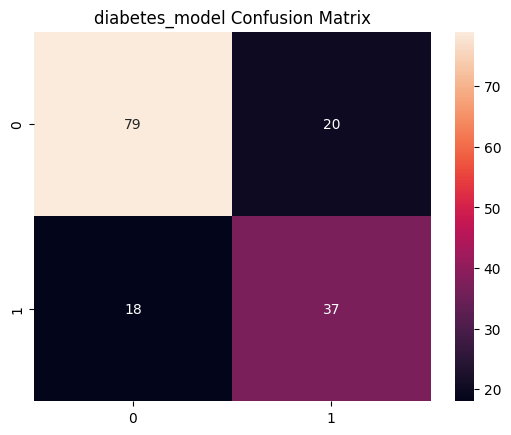

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

✅ Model Saved: models/diabetes_model.pkl



In [43]:
diabetes_df = pd.read_csv(r"C:\Users\dell\Desktop\disease_prediction_system\data\diabetes.csv")
diabetes_acc = train_model(diabetes_df, "Outcome", "diabetes_model")


📊 Training for heart_model...

Logistic Accuracy: 0.7951219512195122
RandomForest Accuracy: 0.9853658536585366
SVM Accuracy: 0.8878048780487805
XGBoost Accuracy: 0.9853658536585366

🏆 Best Model: RandomForest (0.9853658536585366)


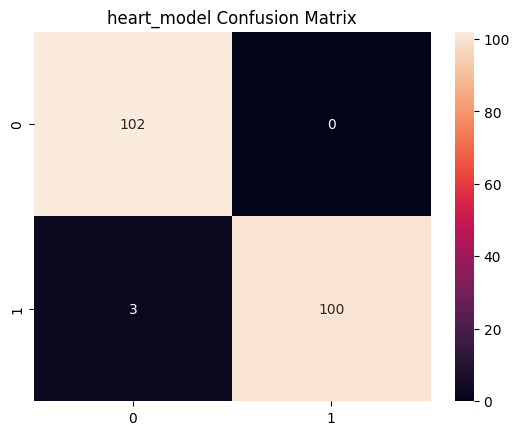

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

✅ Model Saved: models/heart_model.pkl



In [45]:
heart_df = pd.read_csv(r"C:\Users\dell\Desktop\disease_prediction_system\data\heart.csv")
heart_acc = train_model(heart_df, "target", "heart_model")


📊 Training for parkinsons_model...

Columns before select_dtypes: ['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']
Dtypes: name                    str
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE               

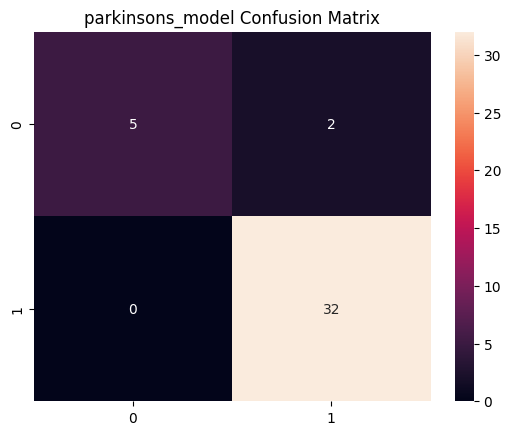

              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39

✅ Model Saved: models/parkinsons_model.pkl



In [52]:
parkinsons_df = pd.read_csv(r"C:\Users\dell\Desktop\disease_prediction_system\data\parkinsons.csv")
parkinsons_acc = train_model(parkinsons_df, "status", "parkinsons_model")

In [65]:
thyroid_df = pd.read_csv(r"C:\Users\dell\Desktop\disease_prediction_system\data\thyroidDF.csv")
thyroid_acc = train_model(thyroid_df, "target", "thyroid_model")


📊 Training for thyroid_model...

Unique y: <StringArray>
[  '-',   'S',   'F',  'AK',   'R',   'I',   'M',   'N',   'G',   'K',   'A',
  'KJ',   'L',  'MK',   'Q',   'J', 'C|I',   'O',  'LJ', 'H|K',   'D',  'GK',
  'MI',   'P',  'FK',   'B',  'GI',   'C', 'GKJ',  'OI', 'D|R',   'E']
Length: 32, dtype: str


ValueError: could not convert string to float: 'F'